In [ ]:
# ============================================================
# Machine Learning Model Development
# Hemoglobinopathy Classification
# ============================================================

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Scikit-Learn
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

path = "/content/drive/MyDrive/Colab Notebooks/Dr_Abdullah/Hemoglobinopathy_Diagnosis_ML/Hemoglobinopathy_Final_Preprocessed.xlsx"

print(path)

/content/drive/MyDrive/Colab Notebooks/Dr_Abdullah/Hemoglobinopathy_Diagnosis_ML/Hemoglobinopathy_Final_Preprocessed.xlsx


In [ ]:
# ============================================================
# Load Final Preprocessed Dataset
# ============================================================

df = pd.read_excel(path)

print("="*60)
print("DATASET LOADED")
print("="*60)

print("Shape :", df.shape)

print("\nMissing Values")
print(df.isnull().sum().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

display(df.head())

DATASET LOADED
Shape : (1539, 15)

Missing Values
0

Duplicate Records
2


,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Results,Hospital
0,32.0,Male,94.6,5.4,0.0,0.0,0.0,6.79,13.3,47.3,69.7,19.7,28.2,Beta Thalassemia Minor,KTH
1,21.0,Female,98.0,2.0,0.0,0.0,0.0,3.88,8.6,29.5,76.0,24.0,31.0,Normal,KTH
2,30.0,Female,97.0,2.1,0.0,0.0,0.0,3.96,7.9,27.8,70.1,19.9,28.4,Normal,KTH
3,2.0,Female,94.3,5.7,0.0,0.0,0.0,6.26,11.8,36.2,57.8,18.8,32.5,Beta Thalassemia Minor,KTH
4,37.0,Female,94.7,5.4,0.0,0.0,0.0,4.42,8.2,27.1,61.4,18.5,30.1,Beta Thalassemia Minor,KTH


In [ ]:
# ============================================================
# Encode Categorical Variables
# ============================================================

gender_encoder = LabelEncoder()
hospital_encoder = LabelEncoder()
target_encoder = LabelEncoder()

df["Gender"] = gender_encoder.fit_transform(df["Gender"])

df["Hospital"] = hospital_encoder.fit_transform(df["Hospital"])

df["Results"] = target_encoder.fit_transform(df["Results"])

print("Encoding Completed\n")

print("Gender Classes")
print(dict(zip(gender_encoder.classes_,
               gender_encoder.transform(gender_encoder.classes_))))

print("\nHospital Classes")
print(dict(zip(hospital_encoder.classes_,
               hospital_encoder.transform(hospital_encoder.classes_))))

print("\nTarget Classes")
print(dict(zip(target_encoder.classes_,
               target_encoder.transform(target_encoder.classes_))))

Encoding Completed

Gender Classes
{'Female': np.int64(0), 'Male': np.int64(1)}

Hospital Classes
{'KTH': np.int64(0), 'Mardan': np.int64(1)}

Target Classes
{'Beta Thalassemia Major': np.int64(0), 'Beta Thalassemia Minor': np.int64(1), 'Borderline HbA2': np.int64(2), 'Hb D Trait': np.int64(3), 'Normal': np.int64(4), 'Sickle Disorders': np.int64(5)}


In [ ]:
# ============================================================
# Define Features and Target
# ============================================================

X = df.drop(["Results", "Hospital"], axis=1)
y = df["Results"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)
print(X.columns)

Feature Matrix Shape : (1539, 13)
Target Shape : (1539,)
Index(['Age', 'Gender', 'Hb-A', 'HB-A2', 'Hb-F', 'Hb-S', 'Hb-D', 'RBC', 'HGB',
       'HCT', 'MCV', 'MCH', 'MCHC'],
      dtype='object')


In [ ]:
# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("TRAIN TEST SPLIT")
print("="*60)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("\nTraining Class Distribution")
print(y_train.value_counts().sort_index())

print("\nTesting Class Distribution")
print(y_test.value_counts().sort_index())

TRAIN TEST SPLIT
Training Samples : 1231
Testing Samples  : 308

Training Class Distribution
Results
0     17
1    280
2     18
3      8
4    894
5     14
Name: count, dtype: int64

Testing Class Distribution
Results
0      5
1     70
2      4
3      2
4    224
5      3
Name: count, dtype: int64


In [ ]:
# ============================================================
# Feature Scaling
# ============================================================

numerical_features = [
    "Age",
    "Hb-A",
    "HB-A2",
    "Hb-F",
    "Hb-S",
    "Hb-D",
    "RBC",
    "HGB",
    "HCT",
    "MCV",
    "MCH",
    "MCHC"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

print("Feature Scaling Completed")

Feature Scaling Completed


In [ ]:
# ============================================================
# Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("TRAIN TEST SPLIT")
print("="*60)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("\nTraining Class Distribution")
print(y_train.value_counts().sort_index())

print("\nTesting Class Distribution")
print(y_test.value_counts().sort_index())

TRAIN TEST SPLIT
Training Samples : 1231
Testing Samples  : 308

Training Class Distribution
Results
0     17
1    280
2     18
3      8
4    894
5     14
Name: count, dtype: int64

Testing Class Distribution
Results
0      5
1     70
2      4
3      2
4    224
5      3
Name: count, dtype: int64


In [ ]:
!pip install imbalanced-learn

In [ ]:
# ============================================================
# Handle Class Imbalance using SMOTE
# ============================================================

from imblearn.over_sampling import SMOTE

print("="*60)
print("CLASS DISTRIBUTION BEFORE SMOTE")
print("="*60)
print(y_train.value_counts().sort_index())

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n" + "="*60)
print("CLASS DISTRIBUTION AFTER SMOTE")
print("="*60)
print(y_train_smote.value_counts().sort_index())

print("\nTraining Shape Before SMOTE :", X_train.shape)
print("Training Shape After SMOTE  :", X_train_smote.shape)

CLASS DISTRIBUTION BEFORE SMOTE
Results
0     17
1    280
2     18
3      8
4    894
5     14
Name: count, dtype: int64

CLASS DISTRIBUTION AFTER SMOTE
Results
0    894
1    894
2    894
3    894
4    894
5    894
Name: count, dtype: int64

Training Shape Before SMOTE : (1231, 13)
Training Shape After SMOTE  : (5364, 13)


In [ ]:
# ============================================================
# Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

numerical_features = [
    "Age",
    "Hb-A",
    "HB-A2",
    "Hb-F",
    "Hb-S",
    "Hb-D",
    "RBC",
    "HGB",
    "HCT",
    "MCV",
    "MCH",
    "MCHC"
]

scaler = StandardScaler()

# Copy data
X_train_scaled = X_train_smote.copy()
X_test_scaled = X_test.copy()

# Scale only numerical variables
X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train_smote[numerical_features]
)

X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

print("="*60)
print("FEATURE SCALING COMPLETED")
print("="*60)

print("Training Shape :", X_train_scaled.shape)
print("Testing Shape  :", X_test_scaled.shape)

display(X_train_scaled.head())

FEATURE SCALING COMPLETED
Training Shape : (5364, 13)
Testing Shape  : (308, 13)


,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC
0,0.020683,0,0.891463,-0.218845,-0.553725,-0.359033,-0.480673,0.085235,1.719840,1.851787,1.335482,1.345157,0.993606
1,0.401609,0,0.900488,-0.451656,-0.553725,-0.359033,-0.480673,-0.154879,0.010501,-0.117121,1.957346,1.521317,0.463471
2,0.325424,0,0.783166,1.798854,-0.521201,-0.359033,-0.480673,0.164206,0.589047,1.066436,-0.393605,-0.539746,-0.390635
3,-1.274463,1,0.915529,-0.839675,-0.553725,-0.359033,-0.480673,-0.069505,-1.278078,-1.355984,-1.925515,-1.949020,-1.745424
4,-1.350648,1,0.882439,-0.684468,-0.524453,-0.359033,-0.480673,0.111915,-0.489152,-0.415775,-1.773841,-1.543853,-0.685154


In [ ]:
# ============================================================
# Stratified Cross Validation
# ============================================================

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [ ]:
# ============================================================
# Model Evaluation Function
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    roc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr"
    )

    print("="*60)
    print(model.__class__.__name__)
    print("="*60)

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Balanced Accuracy : {balanced_acc:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1 Score          : {f1:.4f}")
    print(f"MCC               : {mcc:.4f}")
    print(f"Cohen Kappa       : {kappa:.4f}")
    print(f"ROC-AUC           : {roc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title(model.__class__.__name__)
    plt.show()

    return {
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc,
        "Kappa": kappa,
        "ROC-AUC": roc
    }

LogisticRegression
Accuracy          : 0.8701
Balanced Accuracy : 0.8836
Precision         : 0.9507
Recall            : 0.8701
F1 Score          : 0.9039
MCC               : 0.7472
Cohen Kappa       : 0.7305
ROC-AUC           : 0.9801

Classification Report

              precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.94      0.89      0.91        70
           2       0.10      0.75      0.17         4
           3       0.67      1.00      0.80         2
           4       0.98      0.87      0.92       224
           5       1.00      1.00      1.00         3

    accuracy                           0.87       308
   macro avg       0.71      0.88      0.74       308
weighted avg       0.95      0.87      0.90       308



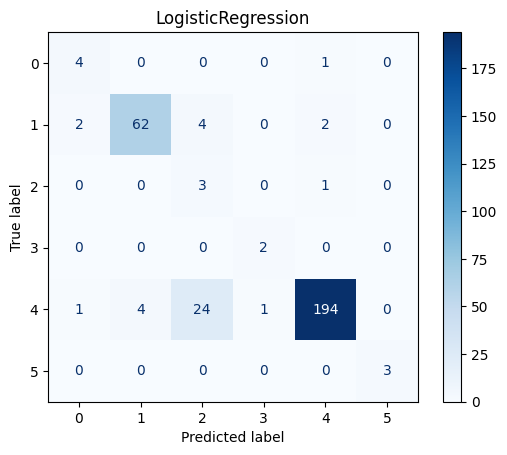

In [ ]:
# ============================================================
# Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_results = evaluate_model(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train_smote,
    y_test
)

Logistic Regression
LogisticRegression
Accuracy          : 0.8701
Balanced Accuracy : 0.8836
Precision         : 0.9507
Recall            : 0.8701
F1 Score          : 0.9039
MCC               : 0.7472
Cohen Kappa       : 0.7305
ROC-AUC           : 0.9801

Classification Report

              precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.94      0.89      0.91        70
           2       0.10      0.75      0.17         4
           3       0.67      1.00      0.80         2
           4       0.98      0.87      0.92       224
           5       1.00      1.00      1.00         3

    accuracy                           0.87       308
   macro avg       0.71      0.88      0.74       308
weighted avg       0.95      0.87      0.90       308



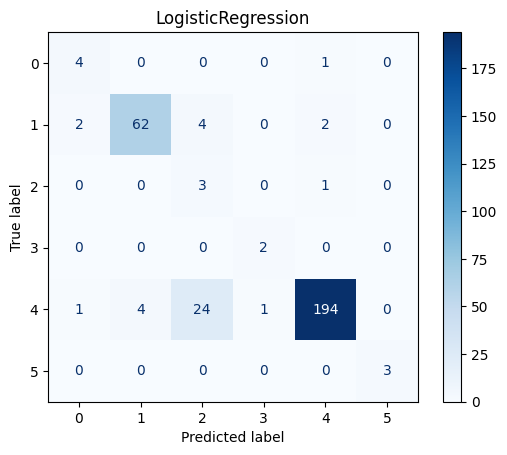

Decision Tree
DecisionTreeClassifier
Accuracy          : 0.9188
Balanced Accuracy : 0.8032
Precision         : 0.9459
Recall            : 0.9188
F1 Score          : 0.9282
MCC               : 0.8232
Cohen Kappa       : 0.8189
ROC-AUC           : 0.8912

Classification Report

              precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.92      0.93      0.92        70
           2       0.29      1.00      0.44         4
           3       1.00      0.50      0.67         2
           4       0.98      0.92      0.95       224
           5       0.50      0.67      0.57         3

    accuracy                           0.92       308
   macro avg       0.71      0.80      0.70       308
weighted avg       0.95      0.92      0.93       308



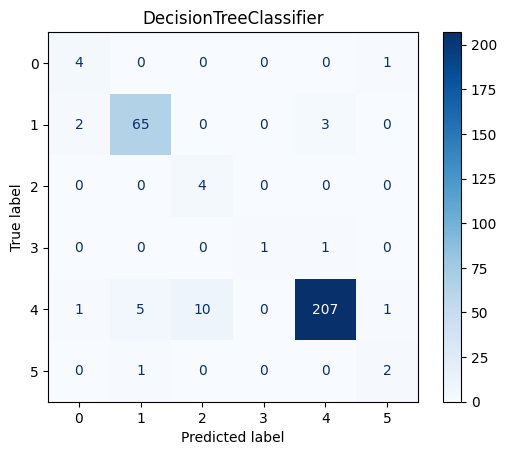

Random Forest
RandomForestClassifier
Accuracy          : 0.9448
Balanced Accuracy : 0.8573
Precision         : 0.9564
Recall            : 0.9448
F1 Score          : 0.9484
MCC               : 0.8743
Cohen Kappa       : 0.8729
ROC-AUC           : 0.9889

Classification Report

              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.93      0.94      0.94        70
           2       0.38      0.75      0.50         4
           3       1.00      0.50      0.67         2
           4       0.98      0.95      0.97       224
           5       1.00      1.00      1.00         3

    accuracy                           0.94       308
   macro avg       0.82      0.86      0.81       308
weighted avg       0.96      0.94      0.95       308



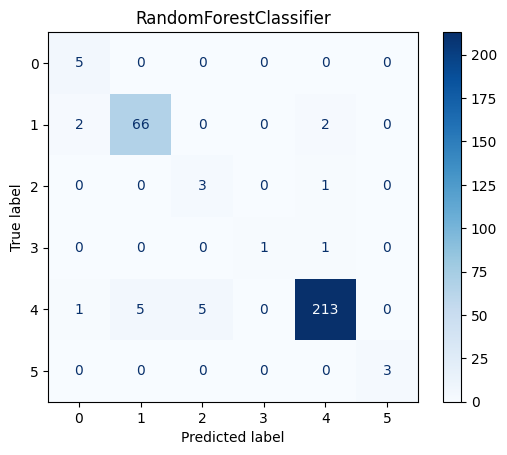

Extra Trees
ExtraTreesClassifier
Accuracy          : 0.9481
Balanced Accuracy : 0.8981
Precision         : 0.9560
Recall            : 0.9481
F1 Score          : 0.9510
MCC               : 0.8807
Cohen Kappa       : 0.8798
ROC-AUC           : 0.9856

Classification Report

              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.92      0.93      0.92        70
           2       0.33      0.50      0.40         4
           3       1.00      1.00      1.00         2
           4       0.99      0.96      0.97       224
           5       1.00      1.00      1.00         3

    accuracy                           0.95       308
   macro avg       0.81      0.90      0.84       308
weighted avg       0.96      0.95      0.95       308



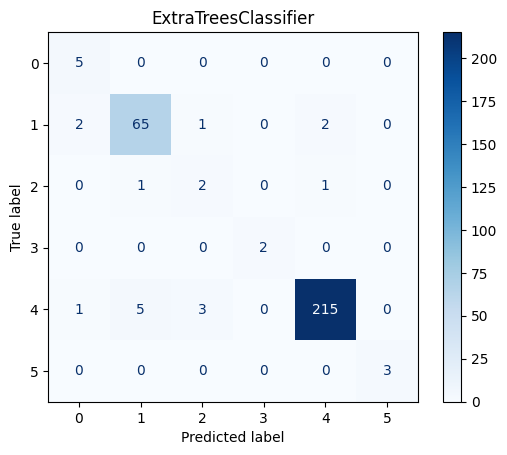

KNN
KNeighborsClassifier
Accuracy          : 0.9026
Balanced Accuracy : 0.8827
Precision         : 0.9453
Recall            : 0.9026
F1 Score          : 0.9207
MCC               : 0.7933
Cohen Kappa       : 0.7867
ROC-AUC           : 0.9548

Classification Report

              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.90      0.89      0.89        70
           2       0.11      0.50      0.18         4
           3       1.00      1.00      1.00         2
           4       0.98      0.91      0.94       224
           5       1.00      1.00      1.00         3

    accuracy                           0.90       308
   macro avg       0.77      0.88      0.80       308
weighted avg       0.95      0.90      0.92       308



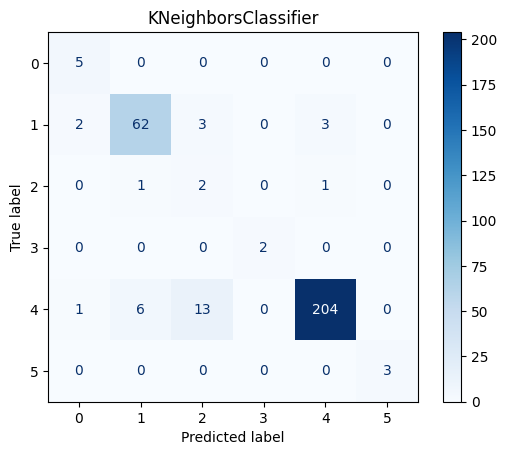

SVM
SVC
Accuracy          : 0.9058
Balanced Accuracy : 0.9293
Precision         : 0.9564
Recall            : 0.9058
F1 Score          : 0.9261
MCC               : 0.8087
Cohen Kappa       : 0.7983
ROC-AUC           : 0.9809

Classification Report

              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.92      0.93      0.92        70
           2       0.14      0.75      0.24         4
           3       1.00      1.00      1.00         2
           4       0.99      0.90      0.94       224
           5       1.00      1.00      1.00         3

    accuracy                           0.91       308
   macro avg       0.78      0.93      0.81       308
weighted avg       0.96      0.91      0.93       308



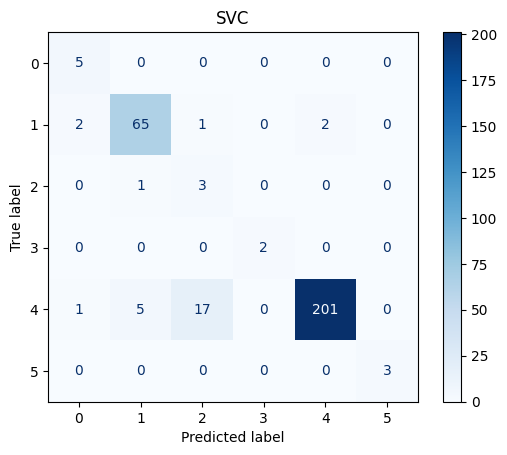

XGBoost
XGBClassifier
Accuracy          : 0.9513
Balanced Accuracy : 0.8179
Precision         : 0.9550
Recall            : 0.9513
F1 Score          : 0.9518
MCC               : 0.8857
Cohen Kappa       : 0.8854
ROC-AUC           : 0.9906

Classification Report

              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.93      0.94      0.94        70
           2       0.50      0.50      0.50         4
           3       1.00      0.50      0.67         2
           4       0.98      0.96      0.97       224
           5       1.00      1.00      1.00         3

    accuracy                           0.95       308
   macro avg       0.84      0.82      0.81       308
weighted avg       0.95      0.95      0.95       308



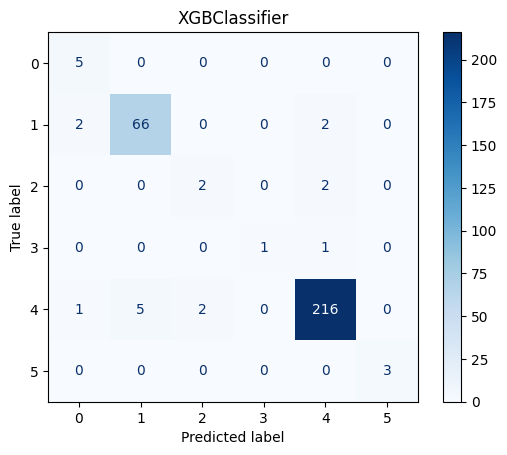

LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000880 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3062
[LightGBM] [Info] Number of data points in the train set: 5364, number of used features: 13
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

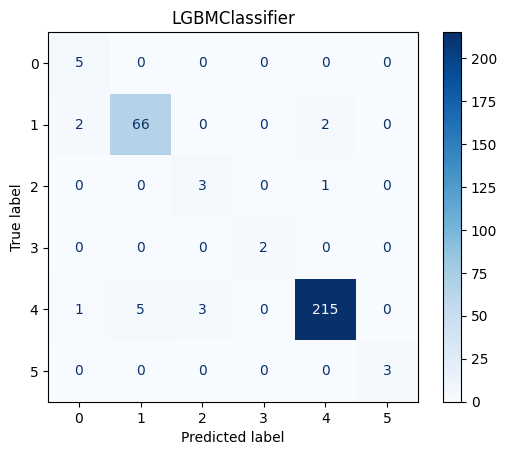

CatBoost
CatBoostClassifier
Accuracy          : 0.9448
Balanced Accuracy : 0.8025
Precision         : 0.9539
Recall            : 0.9448
F1 Score          : 0.9476
MCC               : 0.8732
Cohen Kappa       : 0.8722
ROC-AUC           : 0.9677

Classification Report

              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.93      0.94      0.94        70
           2       0.43      0.75      0.55         4
           3       0.50      0.50      0.50         2
           4       0.98      0.96      0.97       224
           5       1.00      0.67      0.80         3

    accuracy                           0.94       308
   macro avg       0.74      0.80      0.75       308
weighted avg       0.95      0.94      0.95       308



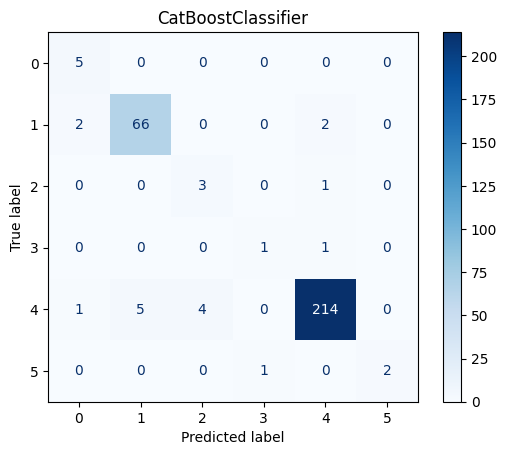

In [ ]:
import warnings
warnings.filterwarnings('ignore')
!pip install catboost

# ============================================================
# TRAIN AND EVALUATE ALL MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42
        ),

    "LightGBM":
        LGBMClassifier(random_state=42),

    "CatBoost":
        CatBoostClassifier(
            verbose=0,
            random_state=42
        )
}

results = []

for name, model in models.items():

    print("="*70)
    print(name)
    print("="*70)

    metrics = evaluate_model(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train_smote,
        y_test
    )

    metrics["Model"] = name

    results.append(metrics)

In [ ]:
# ============================================================
# MODEL COMPARISON
# ============================================================

comparison = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values("F1", ascending=False)
)

comparison = comparison.round(4)

comparison

,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,Kappa,ROC-AUC
Model,,,,,,,,
LightGBM,0.9545,0.9421,0.9614,0.9545,0.9568,0.8957,0.8948,0.9904
XGBoost,0.9513,0.8179,0.9550,0.9513,0.9518,0.8857,0.8854,0.9906
Extra Trees,0.9481,0.8981,0.9560,0.9481,0.9510,0.8807,0.8798,0.9856
Random Forest,0.9448,0.8573,0.9564,0.9448,0.9484,0.8743,0.8729,0.9889
CatBoost,0.9448,0.8025,0.9539,0.9448,0.9476,0.8732,0.8722,0.9677
Decision Tree,0.9188,0.8032,0.9459,0.9188,0.9282,0.8232,0.8189,0.8912
SVM,0.9058,0.9293,0.9564,0.9058,0.9261,0.8087,0.7983,0.9809
KNN,0.9026,0.8827,0.9453,0.9026,0.9207,0.7933,0.7867,0.9548
Logistic Regression,0.8701,0.8836,0.9507,0.8701,0.9039,0.7472,0.7305,0.9801


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=comparison)

https://docs.google.com/spreadsheets/d/1LUoLMYKpoOYqLb31bCBvL0BBaor2gsZDupoEkGoGPQQ/edit#gid=0


In [ ]:

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
    # Add your tuned parameters here if you used tuning
)

xgb_model.fit(X_train_scaled, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
best_model = xgb_model
best_model_name = "XGBoost"

In [ ]:
import joblib

# Save Final Model
joblib.dump(xgb_model, "Hemoglobinopathy_XGBoost_Model.pkl")

# Save Preprocessing Objects
joblib.dump(scaler, "StandardScaler.pkl")
joblib.dump(target_encoder, "Target_LabelEncoder.pkl")
joblib.dump(gender_encoder, "Gender_LabelEncoder.pkl")
joblib.dump(hospital_encoder, "Hospital_LabelEncoder.pkl")

print("="*60)
print("FILES SAVED SUCCESSFULLY")
print("="*60)

FILES SAVED SUCCESSFULLY


In [ ]:
from google.colab import files

files.download("Hemoglobinopathy_XGBoost_Model.pkl")
files.download("StandardScaler.pkl")
files.download("Target_LabelEncoder.pkl")
files.download("Gender_LabelEncoder.pkl")
files.download("Hospital_LabelEncoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# FINAL PREDICTIONS
# ============================================================

y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)

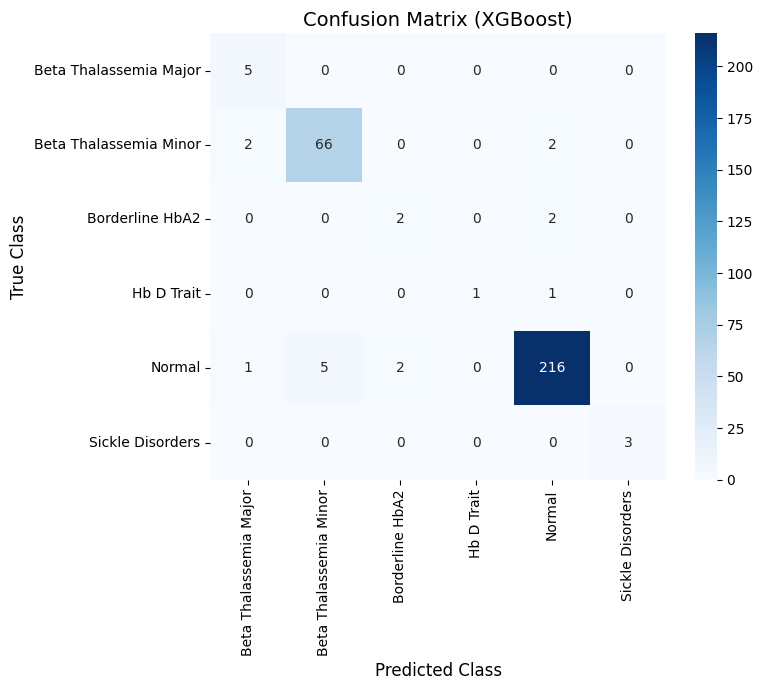

In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = target_encoder.classes_

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Class",fontsize=12)
plt.ylabel("True Class",fontsize=12)
plt.title("Confusion Matrix (XGBoost)",fontsize=14)

plt.tight_layout()

plt.savefig("Figure_Confusion_Matrix.png",dpi=300)

plt.show()

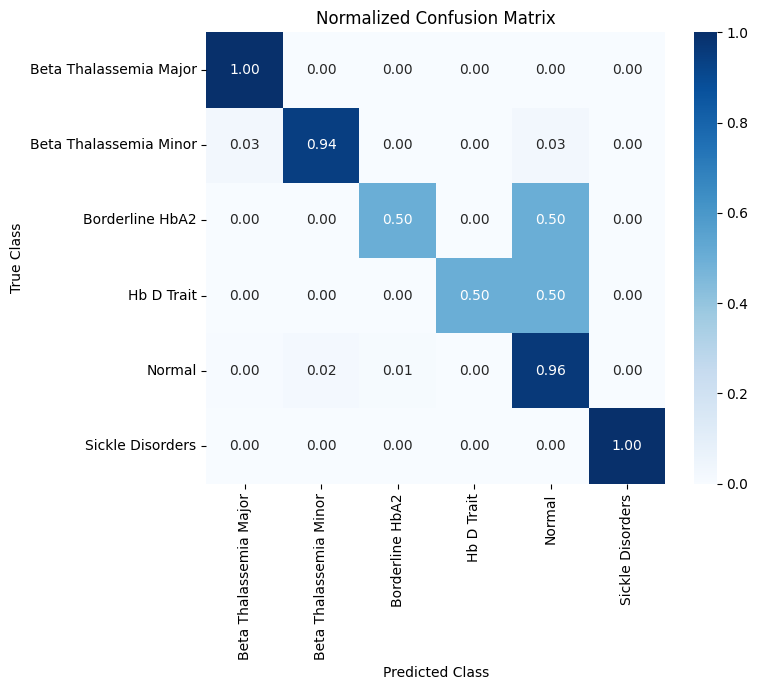

In [ ]:
cm = confusion_matrix(y_test,y_pred,normalize="true")

plt.figure(figsize=(8,7))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()

plt.savefig("Figure_Normalized_CM.png",dpi=300)

plt.show()

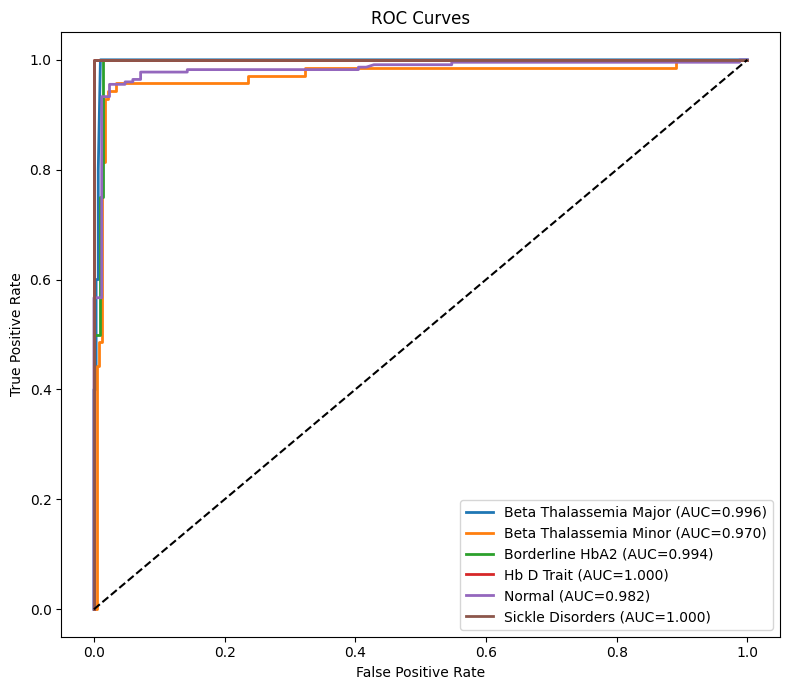

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes=np.unique(y)

y_test_bin=label_binarize(y_test,classes=classes)

plt.figure(figsize=(8,7))

for i in range(len(classes)):

    fpr,tpr,_=roc_curve(y_test_bin[:,i],y_prob[:,i])

    roc_auc=auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{labels[i]} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.tight_layout()

plt.savefig("Figure_ROC.png",dpi=300)

plt.show()

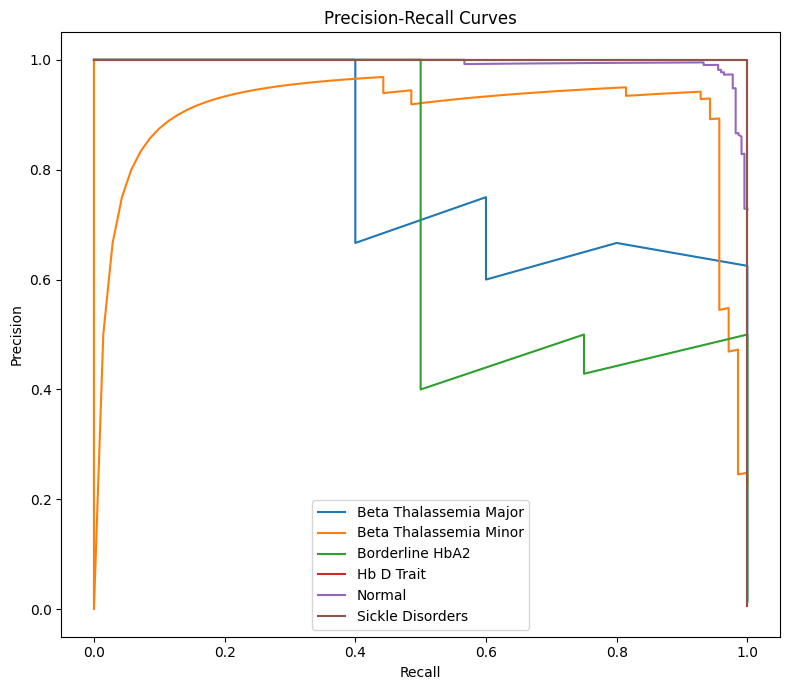

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,7))

for i in range(len(classes)):

    precision,recall,_=precision_recall_curve(
        y_test_bin[:,i],
        y_prob[:,i]
    )

    plt.plot(
        recall,
        precision,
        label=labels[i]
    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curves")

plt.legend()

plt.tight_layout()

plt.savefig("Figure_PR_Curve.png",dpi=300)

plt.show()

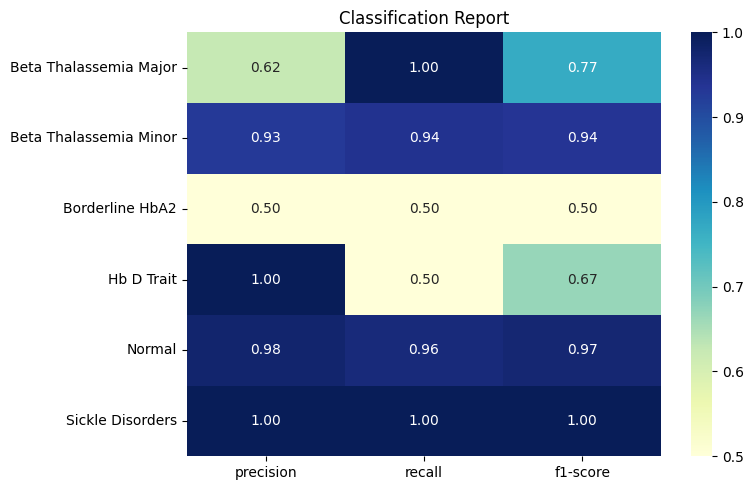

In [ ]:
from sklearn.metrics import classification_report

report=classification_report(
    y_test,
    y_pred,
    target_names=labels,
    output_dict=True
)

report_df=pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))

sns.heatmap(
    report_df.iloc[:-3,:3],
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Classification Report")

plt.tight_layout()

plt.savefig("Figure_Classification_Report.png",dpi=300)

plt.show()

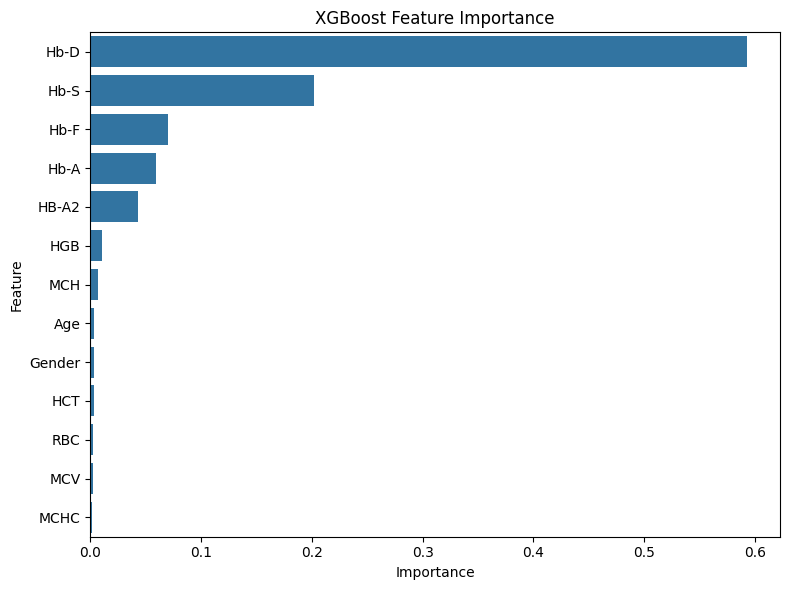

In [ ]:
importance=pd.DataFrame({

"Feature":X.columns,

"Importance":xgb_model.feature_importances_

})

importance=importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    y="Feature",
    x="Importance"
)

plt.title("XGBoost Feature Importance")

plt.tight_layout()

plt.savefig("Figure_XGBoost_Importance.png",dpi=300)

plt.show()

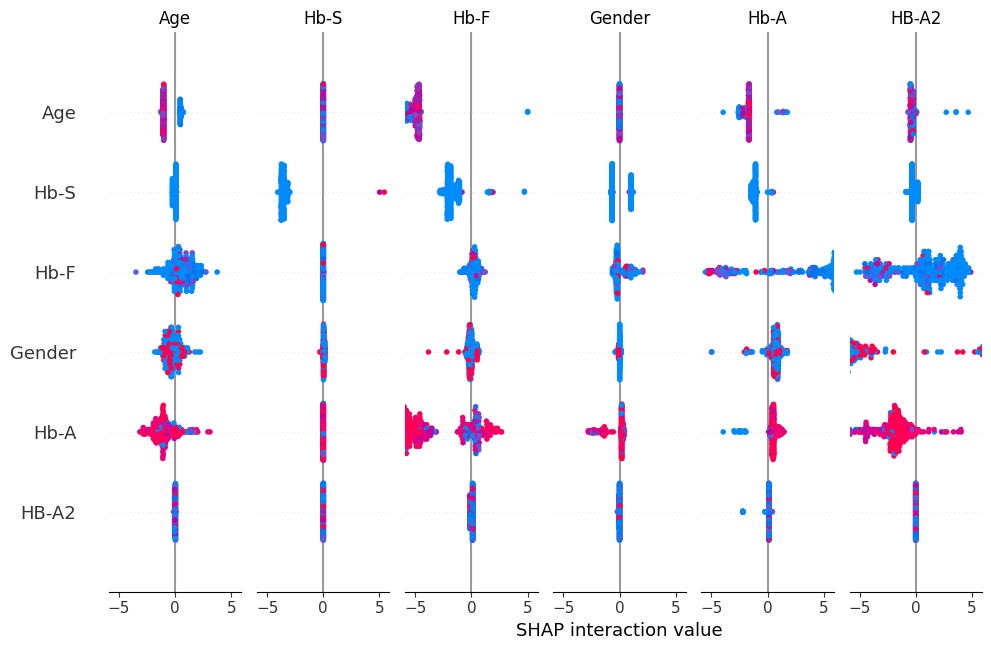

In [ ]:
import shap

explainer=shap.TreeExplainer(xgb_model)

shap_values=explainer.shap_values(X_test_scaled)

shap.summary_plot(
    shap_values,
    X_test_scaled,
    show=False
)

plt.tight_layout()

plt.savefig("Figure_SHAP_Summary.png",dpi=300)

plt.show()

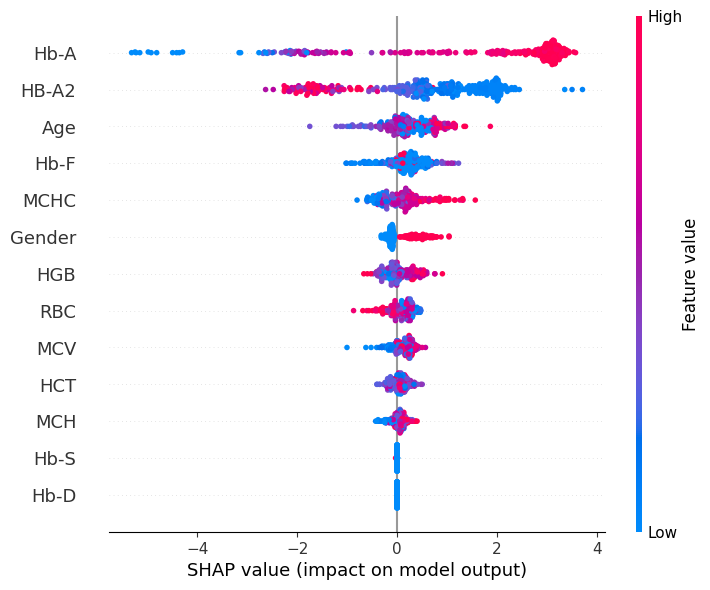

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

class_id = 4      # Normal

shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values[:, :, class_id],
        data=X_test_scaled.values,
        feature_names=X_test_scaled.columns
    ),
    max_display=14
)

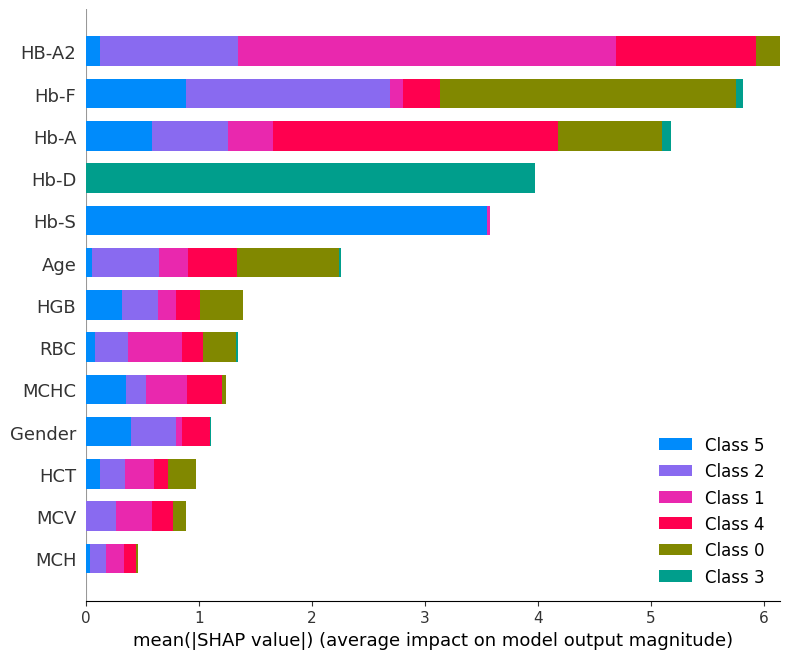

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    plot_type="bar",
    show=False
)

plt.savefig("Figure_SHAP_Bar.png",dpi=300)

plt.show()

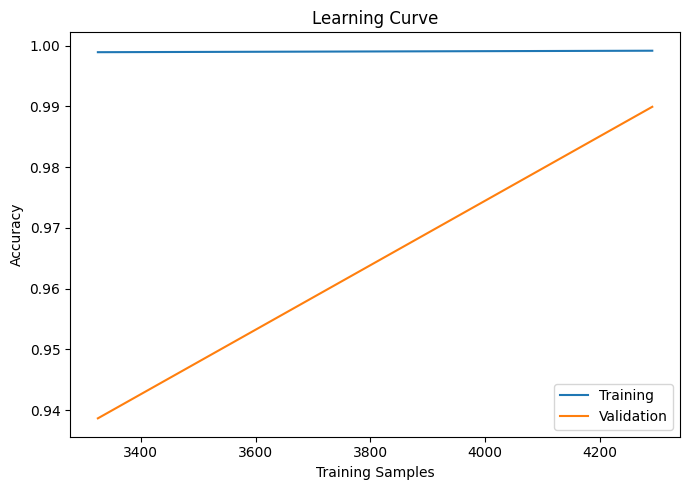

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes,train_scores,test_scores=learning_curve(

xgb_model,

X_train_scaled,

y_train_smote,

cv=5,

scoring="accuracy"

)

train_mean=train_scores.mean(axis=1)

test_mean=test_scores.mean(axis=1)

plt.figure(figsize=(7,5))

plt.plot(train_sizes,train_mean,label="Training")

plt.plot(train_sizes,test_mean,label="Validation")

plt.xlabel("Training Samples")

plt.ylabel("Accuracy")

plt.title("Learning Curve")

plt.legend()

plt.tight_layout()

plt.savefig("Figure_Learning_Curve.png",dpi=300)

plt.show()

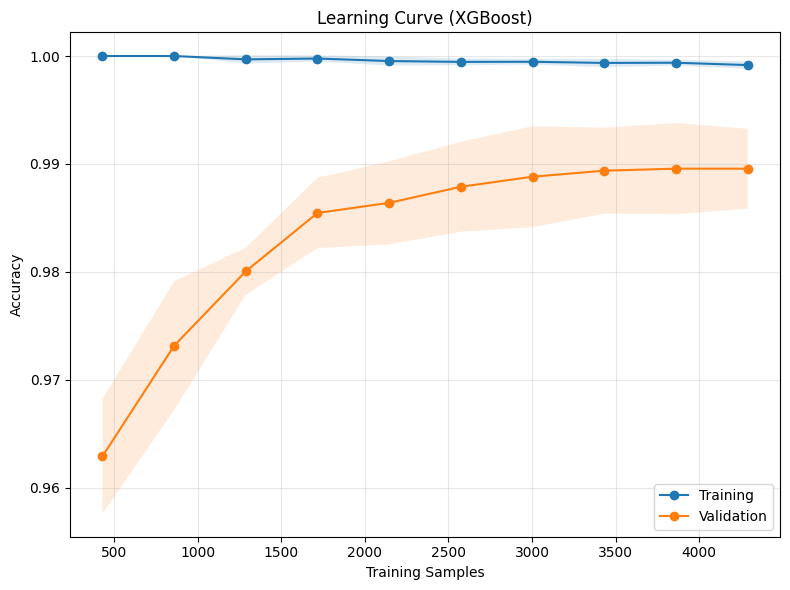

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    estimator=xgb_model,
    X=X_train_scaled,
    y=y_train_smote,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, 'o-', label="Training")
plt.plot(train_sizes, test_mean, 'o-', label="Validation")

plt.fill_between(train_sizes,
                 train_mean-train_std,
                 train_mean+train_std,
                 alpha=0.15)

plt.fill_between(train_sizes,
                 test_mean-test_std,
                 test_mean+test_std,
                 alpha=0.15)

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve (XGBoost)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("Figure_Learning_Curve.png", dpi=300)
plt.show()

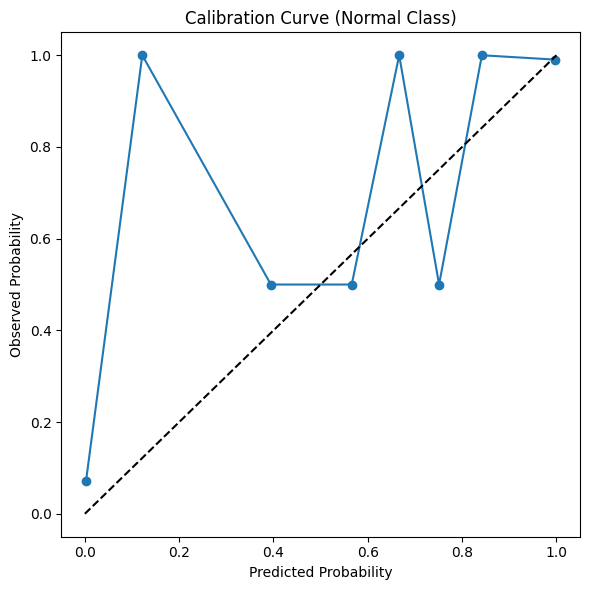

In [ ]:
from sklearn.calibration import calibration_curve

prob_true,prob_pred=calibration_curve(

(y_test==4).astype(int),

y_prob[:,4],

n_bins=10

)

plt.figure(figsize=(6,6))

plt.plot(prob_pred,prob_true,marker='o')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("Predicted Probability")

plt.ylabel("Observed Probability")

plt.title("Calibration Curve (Normal Class)")

plt.tight_layout()

plt.savefig("Figure_Calibration.png",dpi=300)

plt.show()

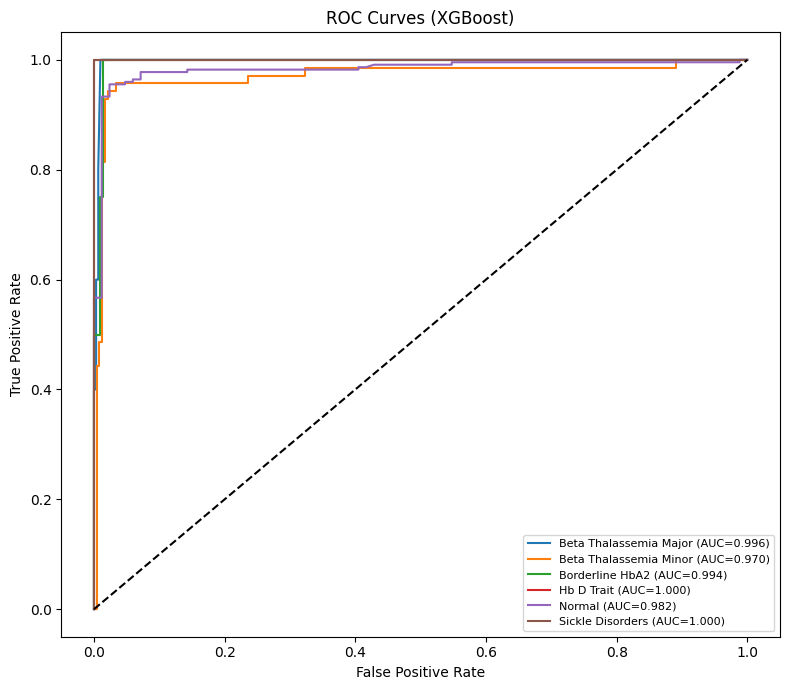

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_score = xgb_model.predict_proba(X_test_scaled)

y_bin = label_binarize(
    y_test,
    classes=range(len(target_encoder.classes_))
)

plt.figure(figsize=(8,7))

for i,class_name in enumerate(target_encoder.classes_):

    fpr,tpr,_=roc_curve(y_bin[:,i],y_score[:,i])

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC={auc(fpr,tpr):.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (XGBoost)")
plt.legend(fontsize=8)

plt.tight_layout()
plt.savefig("Figure_ROC.png",dpi=300)
plt.show()

Final XGBoost Evaluation

                        precision    recall  f1-score   support

Beta Thalassemia Major       0.62      1.00      0.77         5
Beta Thalassemia Minor       0.93      0.94      0.94        70
       Borderline HbA2       0.50      0.50      0.50         4
            Hb D Trait       1.00      0.50      0.67         2
                Normal       0.98      0.96      0.97       224
      Sickle Disorders       1.00      1.00      1.00         3

              accuracy                           0.95       308
             macro avg       0.84      0.82      0.81       308
          weighted avg       0.95      0.95      0.95       308



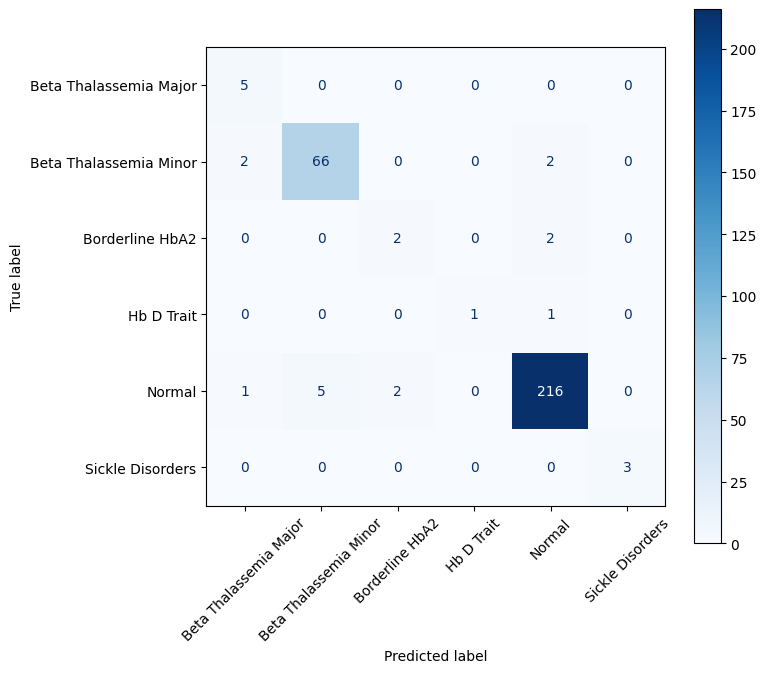

In [ ]:

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Prediction
y_pred = xgb_model.predict(X_test_scaled)

# Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8,7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=target_encoder.classes_,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

plt.tight_layout()
plt.savefig("Figure_ConfusionMatrix.png",dpi=300,bbox_inches="tight")
plt.show()

tables

Table 1 Dataset Summary

In [ ]:
dataset_summary = pd.DataFrame({

"Characteristic":[
"Total Samples",
"Features",
"Classes",
"Missing Values",
"Duplicate Records"
],

"Value":[
len(df),
X.shape[1],
df.Results.nunique(),
df.isna().sum().sum(),
df.duplicated().sum()
]

})

dataset_summary

,Characteristic,Value
0,Total Samples,1539
1,Features,13
2,Classes,6
3,Missing Values,0
4,Duplicate Records,2


Table 2 Class Distribution

In [ ]:
table2 = pd.DataFrame({

"Diagnosis":df.Results.value_counts().index,

"Count":df.Results.value_counts().values,

"Percentage (%)":(
df.Results.value_counts(normalize=True)*100
).round(2)

})

table2

,Diagnosis,Count,Percentage (%)
Results,,,
4,4,1118,72.64
1,1,350,22.74
2,2,22,1.43
0,0,22,1.43
5,5,17,1.10
3,3,10,0.65


Table 3 Descriptive Statistics

In [ ]:
table3 = df.describe().T.round(2)

table3

,count,mean,std,min,25%,50%,75%,max
Age,1539.0,19.60,13.70,0.0,6.00,20.00,28.00,80.0
Gender,1539.0,0.39,0.49,0.0,0.00,0.00,1.00,1.0
Hb-A,1539.0,93.98,13.65,0.0,95.30,97.30,97.90,99.0
HB-A2,1539.0,2.91,1.23,0.0,2.00,2.40,3.30,9.4
Hb-F,1539.0,2.09,10.72,0.0,0.00,0.00,0.80,94.3
Hb-S,1539.0,0.39,4.30,0.0,0.00,0.00,0.00,67.0
Hb-D,1539.0,0.29,3.34,0.0,0.00,0.00,0.00,63.2
RBC,1539.0,4.84,12.65,0.0,3.95,4.54,5.15,499.0
HGB,1539.0,9.96,4.60,1.6,7.90,9.40,11.70,113.0
HCT,1539.0,33.39,8.84,5.8,27.95,32.30,38.40,86.1


Table 4 Mean Feature Values per Disease

In [ ]:
table4 = (

df.groupby("Results")

.mean(numeric_only=True)

.round(2)

)

table4

,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Hospital
Results,,,,,,,,,,,,,,
0,1.75,0.41,15.75,1.39,74.05,0.00,0.00,2.69,5.70,18.62,68.35,21.59,30.71,0.32
1,22.48,0.39,93.00,4.85,1.81,0.07,0.01,6.65,10.29,33.82,64.30,18.83,29.18,0.20
2,18.64,0.27,95.42,3.10,1.40,0.00,0.00,3.93,7.98,27.29,70.00,21.53,29.91,0.50
3,22.80,0.40,67.06,2.94,0.08,0.00,33.12,4.60,10.90,35.39,76.98,23.29,30.43,0.10
4,19.08,0.39,96.92,2.32,0.55,0.00,0.00,4.35,9.98,33.70,76.96,23.13,30.19,0.23
5,17.41,0.88,36.13,3.94,18.31,33.55,6.51,4.17,9.65,30.14,76.34,27.14,30.74,0.06


Table 5 Kruskal-Wallis Results

In [ ]:
from scipy.stats import kruskal

kruskal_data = []

for feature in numerical_features:
    groups = [X[feature][y == cls] for cls in np.unique(y)]
    h_statistic, p_value = kruskal(*groups)
    kruskal_data.append({"Feature": feature, "H Statistic": h_statistic, "P-value": p_value})

kruskal_results = pd.DataFrame(kruskal_data)

kruskal_results.sort_values(
"H Statistic",
ascending=False
)

,Feature,H Statistic,P-value
5,Hb-D,1122.248029,2.032588e-240
4,Hb-S,1089.620044,2.365595e-233
2,HB-A2,813.385864,1.470173e-173
1,Hb-A,774.823743,3.231957e-165
6,RBC,269.887070,2.959224e-56
9,MCV,260.986644,2.411010e-54
3,Hb-F,181.750014,2.262898e-37
10,MCH,178.030124,1.409634e-36
8,HCT,61.619682,5.621102e-12
0,Age,60.625735,9.024045e-12


Table 6 Feature Importance

In [ ]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":xgb_model.feature_importances_

})

importance=importance.sort_values(

"Importance",

ascending=False

)

importance

,Feature,Importance
6,Hb-D,0.593094
5,Hb-S,0.202048
4,Hb-F,0.069749
2,Hb-A,0.059450
3,HB-A2,0.042647
8,HGB,0.010665
11,MCH,0.006767
0,Age,0.003697
1,Gender,0.003267
9,HCT,0.002993


Table 8 Classification Report

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(

y_test,

y_pred,

target_names=target_encoder.classes_,

output_dict=True

)

table8 = pd.DataFrame(report).transpose()

table8

,precision,recall,f1-score,support
Beta Thalassemia Major,0.625000,1.000000,0.769231,5.000000
Beta Thalassemia Minor,0.929577,0.942857,0.936170,70.000000
Borderline HbA2,0.500000,0.500000,0.500000,4.000000
Hb D Trait,1.000000,0.500000,0.666667,2.000000
Normal,0.977376,0.964286,0.970787,224.000000
Sickle Disorders,1.000000,1.000000,1.000000,3.000000
accuracy,0.951299,0.951299,0.951299,0.951299
macro avg,0.838659,0.817857,0.807142,308.000000
weighted avg,0.954960,0.951299,0.951843,308.000000


Table 9 Confusion Matrix

In [ ]:
cm = pd.DataFrame(

confusion_matrix(y_test,y_pred),

index=target_encoder.classes_,

columns=target_encoder.classes_

)

cm

,Beta Thalassemia Major,Beta Thalassemia Minor,Borderline HbA2,Hb D Trait,Normal,Sickle Disorders
Beta Thalassemia Major,5,0,0,0,0,0
Beta Thalassemia Minor,2,66,0,0,2,0
Borderline HbA2,0,0,2,0,2,0
Hb D Trait,0,0,0,1,1,0
Normal,1,5,2,0,216,0
Sickle Disorders,0,0,0,0,0,3


Table 10 Hyperparameters

In [ ]:
params = pd.DataFrame({

"Hyperparameter":[
"n_estimators",
"learning_rate",
"max_depth",
"subsample",
"colsample_bytree",
"gamma",
"min_child_weight"
],

"Value":[
xgb_model.get_params()["n_estimators"],
xgb_model.get_params()["learning_rate"],
xgb_model.get_params()["max_depth"],
xgb_model.get_params()["subsample"],
xgb_model.get_params()["colsample_bytree"],
xgb_model.get_params()["gamma"],
xgb_model.get_params()["min_child_weight"]
]

})

params

,Hyperparameter,Value
0,n_estimators,None
1,learning_rate,None
2,max_depth,None
3,subsample,None
4,colsample_bytree,None
5,gamma,None
6,min_child_weight,None


Table 11 Per-Class ROC-AUC

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

classes=np.unique(y)

y_bin=label_binarize(y_test,classes=classes)

auc_scores=[]

for i,name in enumerate(target_encoder.classes_):

    auc_scores.append(

        roc_auc_score(

            y_bin[:,i],

            y_prob[:,i]

        )

    )

table11=pd.DataFrame({

"Class":target_encoder.classes_,

"ROC-AUC":np.round(auc_scores,4)

})

table11

,Class,ROC-AUC
0,Beta Thalassemia Major,0.9964
1,Beta Thalassemia Minor,0.9702
2,Borderline HbA2,0.9942
3,Hb D Trait,1.0000
4,Normal,0.9825
5,Sickle Disorders,1.0000


In [ ]:
print(X.columns)

Index(['Age', 'Gender', 'Hb-A', 'HB-A2', 'Hb-F', 'Hb-S', 'Hb-D', 'RBC', 'HGB',
       'HCT', 'MCV', 'MCH', 'MCHC'],
      dtype='object')


<Figure size 800x600 with 0 Axes>

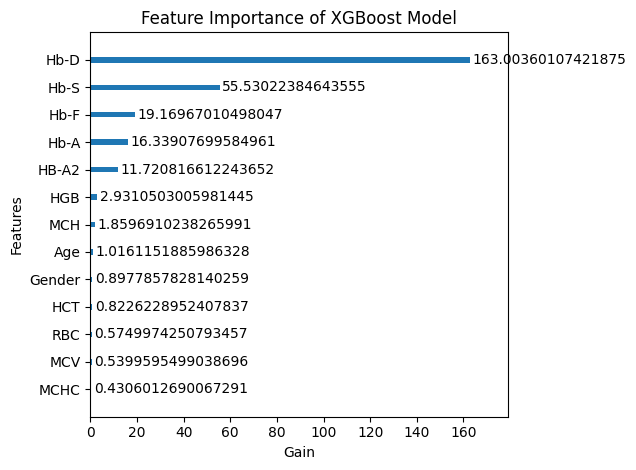

In [ ]:
# ============================================================
# FIGURE 6
# XGBOOST FEATURE IMPORTANCE
# ============================================================

from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plot_importance(
    xgb_model,
    max_num_features=13,
    importance_type="gain",
    xlabel="Gain",
    grid=False
)

plt.title("Feature Importance of XGBoost Model")

plt.tight_layout()

plt.savefig(
    "Figure6_XGBoost_FeatureImportance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

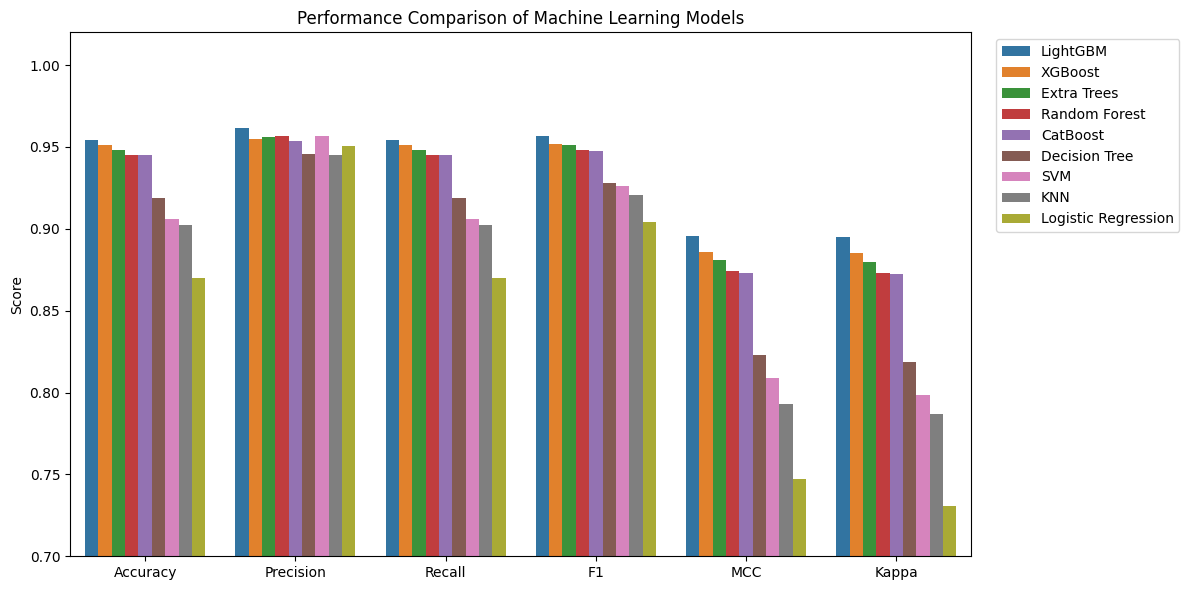

In [ ]:
# ============================================================
# FIGURE 7
# MODEL PERFORMANCE COMPARISON
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "Kappa"
]

plot_df = comparison.reset_index().melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0.70,1.02)

plt.ylabel("Score")
plt.xlabel("")
plt.title("Performance Comparison of Machine Learning Models")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "Figure7_Model_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print(X_test_scaled.shape)
print(y_test.shape)

(308, 13)
(308,)


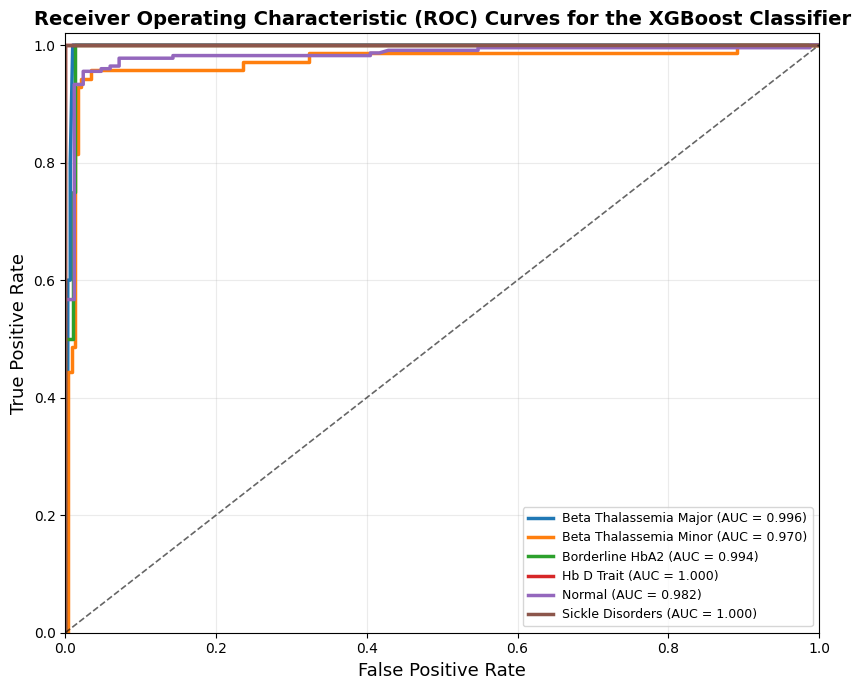

In [ ]:
# ============================================================
# FIGURE 8
# PUBLICATION-QUALITY ROC CURVES
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Predict probabilities
y_prob = xgb_model.predict_proba(X_test_scaled)

# Binarize labels
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

class_names = target_encoder.classes_

plt.figure(figsize=(8.5,7))

colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b"
]

for i, color in enumerate(colors):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        color=color,
        lw=2.5,
        label=f"{class_names[i]} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='black',
    lw=1.2,
    alpha=0.6
)

plt.xlim([0,1])
plt.ylim([0,1.02])

plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)

plt.title(
    "Receiver Operating Characteristic (ROC) Curves for the XGBoost Classifier",
    fontsize=14,
    weight="bold"
)

plt.grid(alpha=0.25)

plt.legend(
    loc="lower right",
    fontsize=9,
    frameon=True
)

plt.tight_layout()

plt.savefig(
    "Figure8_ROC_Curves_XGBoost.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

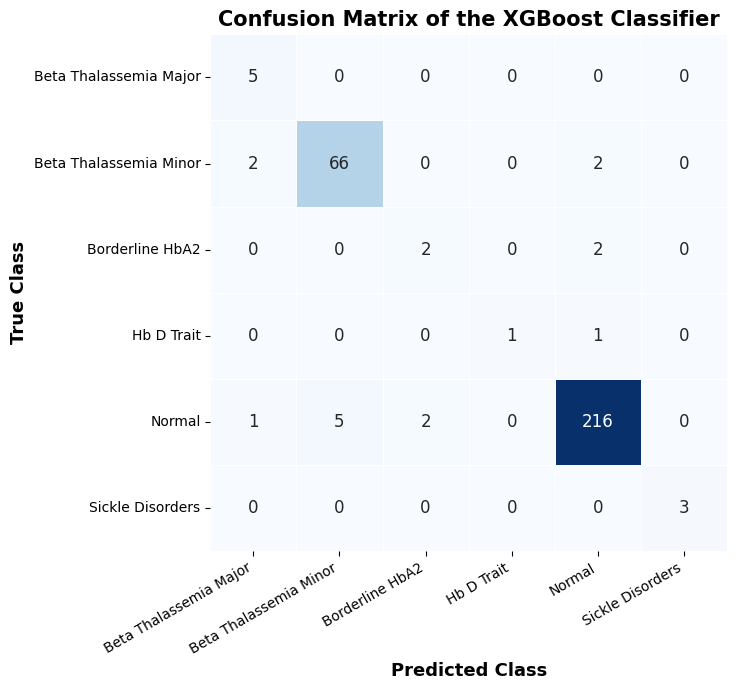

In [ ]:
# ============================================================
# FIGURE 9
# CONFUSION MATRIX (XGBOOST)
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = xgb_model.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    square=True,
    cbar=False,
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_,
    annot_kws={"size":12}
)

plt.xlabel("Predicted Class", fontsize=13, weight="bold")
plt.ylabel("True Class", fontsize=13, weight="bold")

plt.title(
    "Confusion Matrix of the XGBoost Classifier",
    fontsize=15,
    weight="bold"
)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "Figure9_ConfusionMatrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
type(shap_values)

numpy.ndarray

In [ ]:
np.array(shap_values).shape

(308, 13, 6)

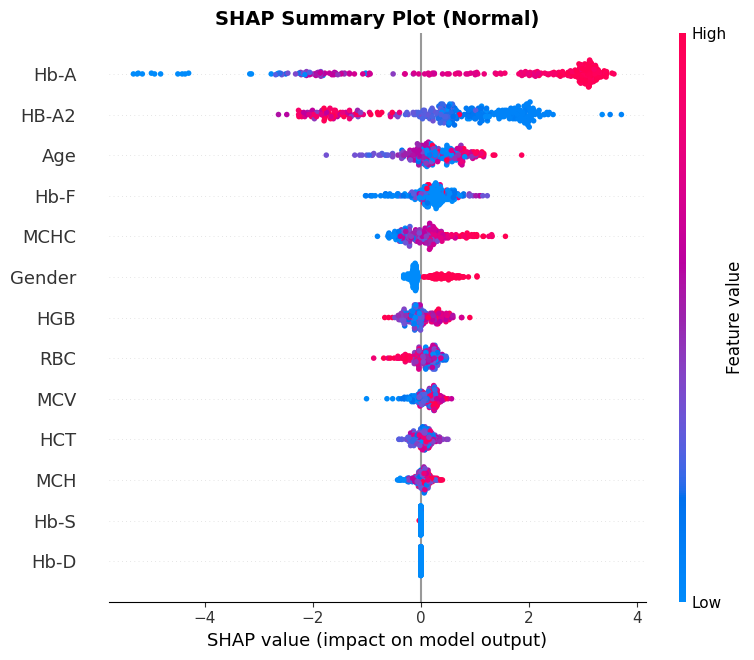

In [ ]:
# ============================================================
# FIGURE 10
# SHAP SUMMARY PLOT
# ============================================================

import shap
import matplotlib.pyplot as plt

class_index = 4      # Normal

shap.summary_plot(
    shap_values[:, :, class_index],
    X_test_scaled,
    feature_names=X.columns,
    show=False
)

plt.title(
    f"SHAP Summary Plot ({target_encoder.classes_[class_index]})",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure10_SHAP_Summary.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

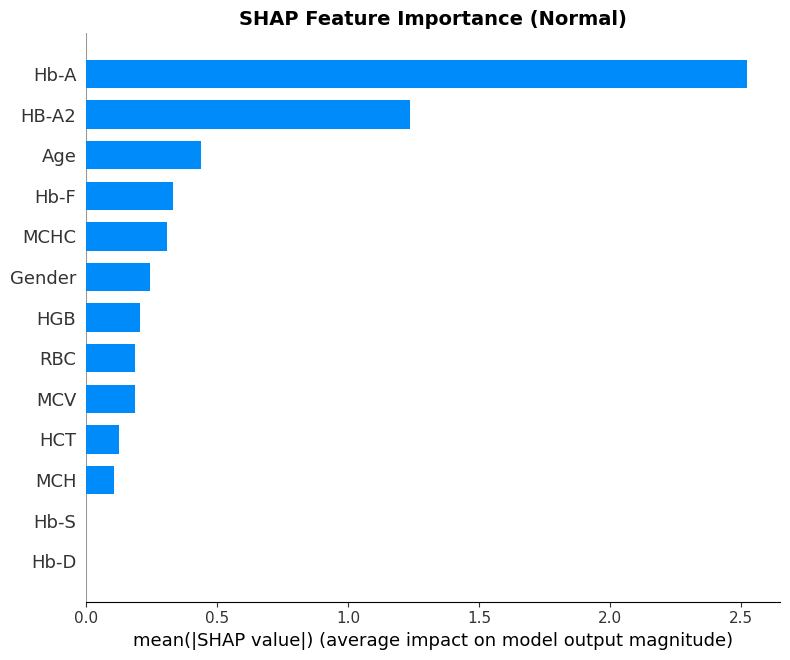

In [ ]:
# ============================================================
# FIGURE 11
# SHAP FEATURE IMPORTANCE
# ============================================================

shap.summary_plot(
    shap_values[:, :, class_index],
    X_test_scaled,
    feature_names=X.columns,
    plot_type="bar",
    show=False
)

plt.title(
    f"SHAP Feature Importance ({target_encoder.classes_[class_index]})",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure11_SHAP_Bar.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

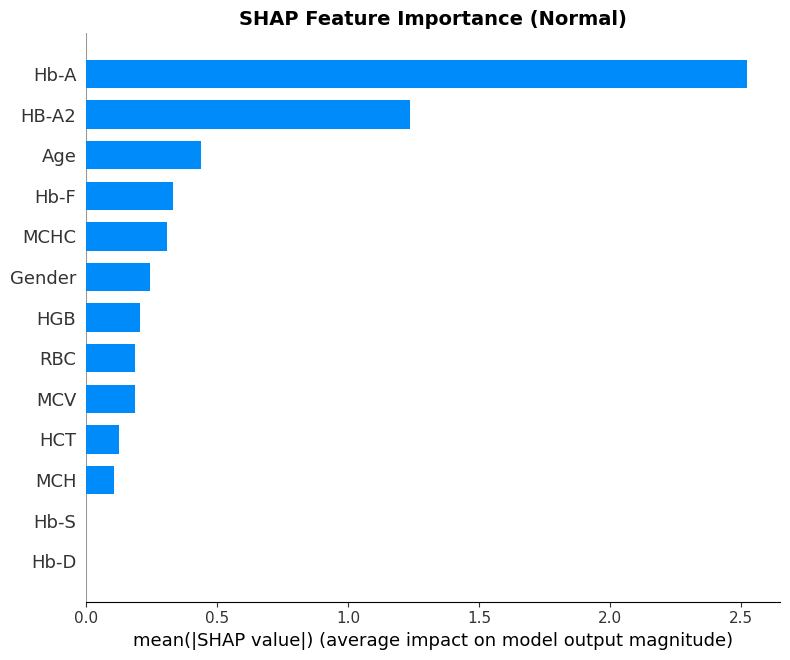

In [ ]:
# ============================================================
# FIGURE 11
# SHAP FEATURE IMPORTANCE
# ============================================================

shap.summary_plot(
    shap_values[:, :, class_index],
    X_test_scaled,
    feature_names=X.columns,
    plot_type="bar",
    show=False
)

plt.title(
    f"SHAP Feature Importance ({target_encoder.classes_[class_index]})",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure11_SHAP_Bar.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

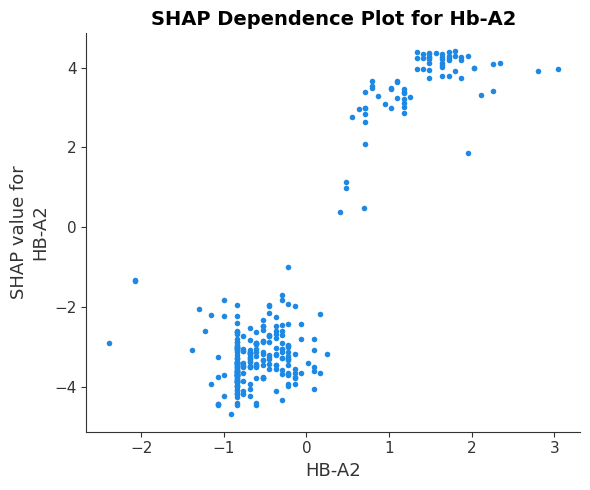

In [ ]:
# ============================================================
# FIGURE 12
# SHAP DEPENDENCE PLOT - Hb-A2
# ============================================================

import shap
import matplotlib.pyplot as plt

class_index = 1   # Beta Thalassemia Minor

shap.dependence_plot(
    "HB-A2",
    shap_values[:, :, class_index],
    X_test_scaled,
    feature_names=X.columns,
    interaction_index=None,
    show=False
)

plt.title(
    "SHAP Dependence Plot for Hb-A2",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure12_SHAP_HbA2.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

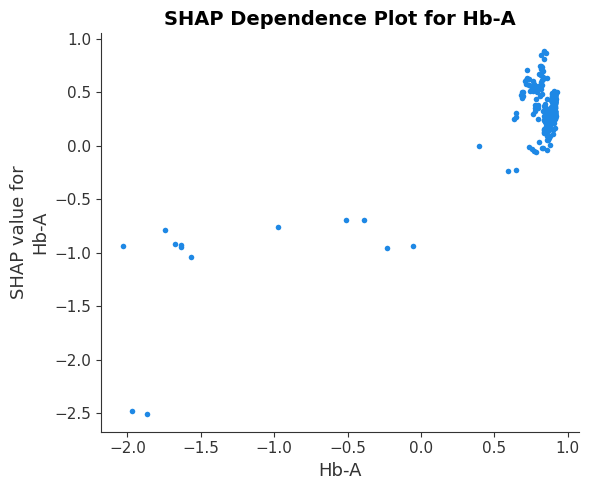

In [ ]:
# ============================================================
# FIGURE 13
# SHAP DEPENDENCE PLOT - Hb-A
# ============================================================

shap.dependence_plot(
    "Hb-A",
    shap_values[:, :, class_index],
    X_test_scaled,
    feature_names=X.columns,
    interaction_index=None,
    show=False
)

plt.title(
    "SHAP Dependence Plot for Hb-A",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure13_SHAP_HbA.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print(models.keys())

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'KNN', 'SVM', 'XGBoost', 'LightGBM', 'CatBoost'])


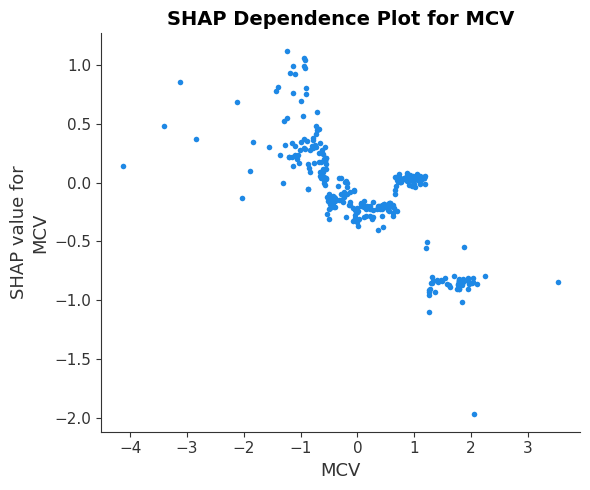

In [ ]:
# ============================================================
# FIGURE 14
# SHAP DEPENDENCE PLOT - MCV
# ============================================================

shap.dependence_plot(
    "MCV",
    shap_values[:, :, class_index],
    X_test_scaled,
    feature_names=X.columns,
    interaction_index=None,
    show=False
)

plt.title(
    "SHAP Dependence Plot for MCV",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure14_SHAP_MCV.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# FIND A CORRECTLY CLASSIFIED BETA THALASSEMIA MINOR SAMPLE
# ============================================================

class_index = 1   # Beta Thalassemia Minor

indices = np.where(
    (y_test == class_index) &
    (y_pred == class_index)
)[0]

indices

array([  1,   4,   6,   7,   9,  10,  13,  14,  21,  23,  24,  41,  45,
        48,  70,  86,  91,  96, 103, 104, 113, 114, 116, 123, 126, 131,
       143, 149, 156, 161, 163, 165, 170, 181, 184, 189, 192, 197, 199,
       200, 203, 205, 206, 207, 208, 209, 216, 219, 220, 222, 229, 231,
       236, 248, 251, 254, 256, 261, 268, 269, 271, 274, 283, 285, 296,
       298])

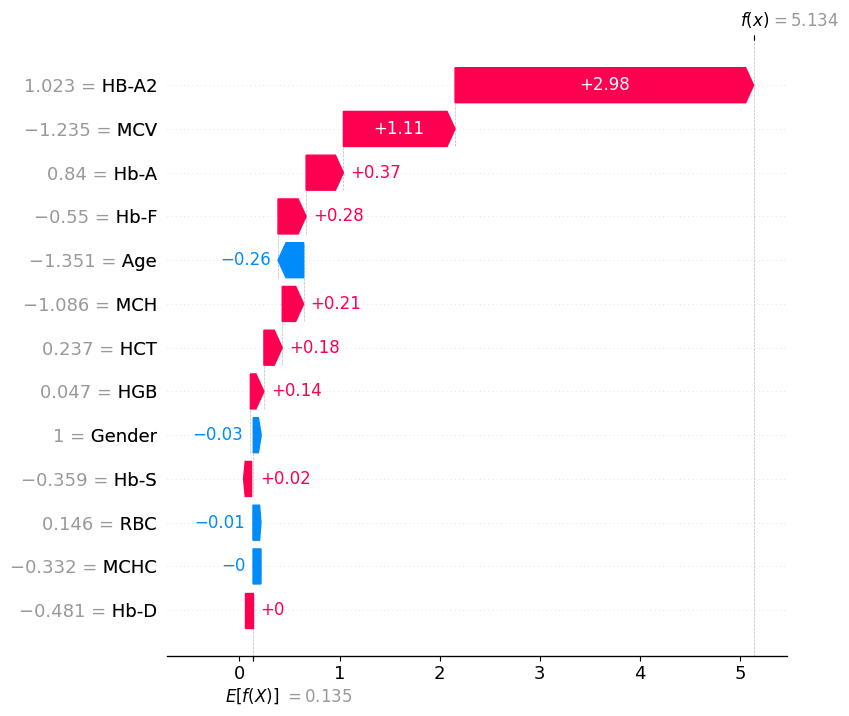

In [ ]:
# ============================================================
# FIGURE 15
# SHAP WATERFALL - BETA THALASSEMIA MINOR
# ============================================================

sample = indices[0]

exp = shap.Explanation(
    values=shap_values[sample, :, class_index],
    base_values=explainer.expected_value[class_index],
    data=X_test_scaled.iloc[sample],
    feature_names=X.columns
)

plt.figure(figsize=(8,6))

shap.plots.waterfall(
    exp,
    max_display=13,
    show=False
)

plt.savefig(
    "Figure15_SHAP_Waterfall_BTM.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

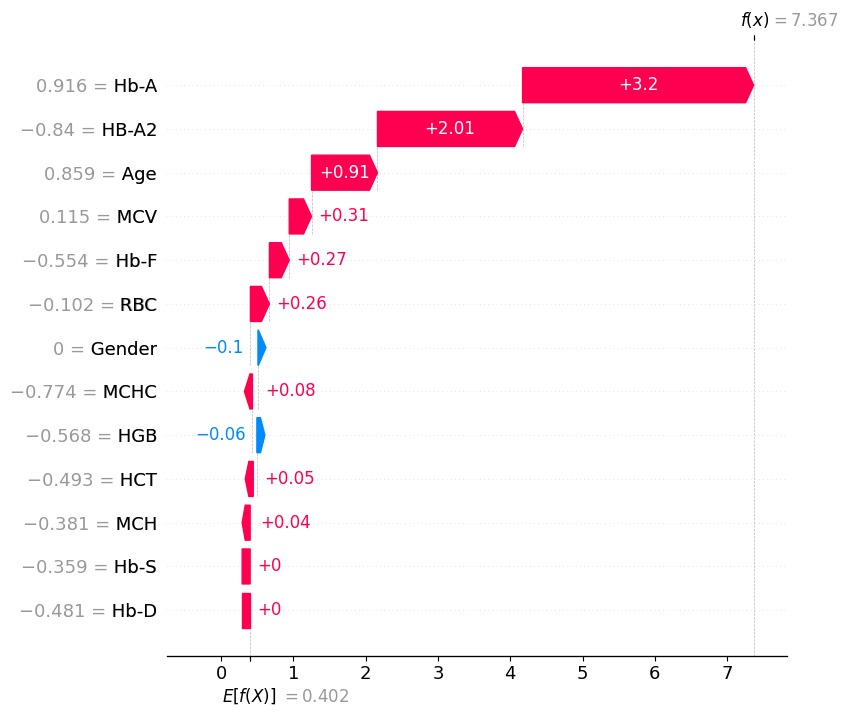

In [ ]:
# ============================================================
# 16 FIND A CORRECTLY CLASSIFIED NORMAL SAMPLE
# ============================================================

class_index = 4

indices = np.where(
    (y_test == class_index) &
    (y_pred == class_index)
)[0]

sample = indices[0]

exp = shap.Explanation(
    values=shap_values[sample, :, class_index],
    base_values=explainer.expected_value[class_index],
    data=X_test_scaled.iloc[sample],
    feature_names=X.columns
)

plt.figure(figsize=(8,6))

shap.plots.waterfall(
    exp,
    max_display=13,
    show=False
)

plt.savefig(
    "Figure16_SHAP_Waterfall_Normal.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

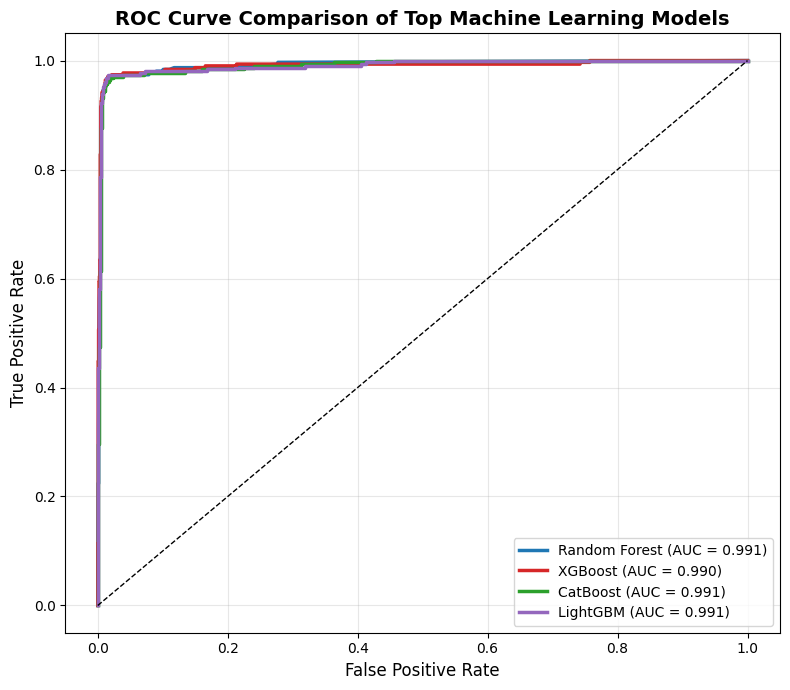

In [ ]:
# ============================================================
# FIGURE 4
# ROC CURVE COMPARISON OF TOP 4 MODELS
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Top models
top_models = {
    "Random Forest": models["Random Forest"],
    "XGBoost": models["XGBoost"],
    "CatBoost": models["CatBoost"],
    "LightGBM": models["LightGBM"]
}

# Binarize test labels
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,7))

colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]

for (name, model), color in zip(top_models.items(), colors):

    # Predicted probabilities
    y_prob = model.predict_proba(X_test_scaled)

    # Micro-average ROC
    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        y_prob.ravel()
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2.5,
        color=color,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    lw=1
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    "ROC Curve Comparison of Top Machine Learning Models",
    fontsize=14,
    weight="bold"
)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figure4_ROC_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# XGBOOST HYPERPARAMETER TUNING
# ============================================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=6,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3, 0.5],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 2, 5]
}

In [207]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring="f1_weighted",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_scaled, y_train_smote)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.03, 0.05, 0.1,
                                                          0.2],
                                        'max_depth': [3, 4, 5, 6, 8, 10],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [100, 200, 300, 500],
                                        'reg_alpha': [0, 0.01, 0.1, 1],
                                        'reg_lambda': [0.5, 1, 2, 5],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='f1_weighted', verbose=2)

In [208]:
print("Best Parameters")
print(random_search.best_params_)

print("\nBest Cross Validation Score")
print(random_search.best_score_)

Best Parameters
{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.9}

Best Cross Validation Score
0.9910363818784816


In [211]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    balanced_accuracy_score
)

best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1:", f1_score(y_test, y_pred, average="weighted"))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))

Accuracy: 0.948051948051948
Balanced Accuracy: 0.8580357142857143
Precision: 0.957141612033694
Recall: 0.948051948051948
F1: 0.9506434988002858
MCC: 0.8807479923472449
Kappa: 0.8797550203743015
